# Pipeline 3 — Temporal Particle Tracking End-to-End Test

This notebook processes a multi-frame sequence through the full Pipeline 3:
- Frame 0: Pipeline 1 cold-start (BestFirstSearcher)
- Frame 1+: IMU-predicted particle-guided two-pass search + meta-tile + semantic confirmation

Outputs: JSONL logs, meta-tiles, trajectory CSV, summary metrics.

In [1]:
# Cell 1 — Setup
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from config import config
from src.tile_utils import TileLoader, haversine_distance
from src.image_utils import load_image
from src.geometric_matcher import initialize_matcher
from src.semantic_model import load_semantic_model
from src.temporal_searcher import TemporalSearcher
from src.ekf_ins import preprocess_imu_csv

config.ensure_output_dirs()
print('Setup complete')

Setup complete


In [2]:
# Cell 2 — Load data + warmup ONLINE EKF to START_ROW
from src.ekf_ins import preprocess_imu_csv, ErrorStateEKF, step_ekf, barometric_altitude
from src.tile_utils import tile_to_latlon

# Run batch EKF for reference / GT comparison (unchanged)
imu_log = preprocess_imu_csv(config.IMU_CSV_PATH)
print(f'IMU log: {len(imu_log)} rows')

# Build frame list: match CSV timestamps to frame files
frame_dir = config.QUERY_FRAMES_DIR
frame_files = sorted(frame_dir.glob('frame_*.jpg'))
print(f'Found {len(frame_files)} frames')

frame_map = {}
for fp in frame_files:
    ts_str = fp.stem.replace('frame_', '')
    try:
        ts = float(ts_str)
        frame_map[round(ts, 3)] = fp
    except ValueError:
        continue

# Reference map bounds
south_lat, west_lon = tile_to_latlon(config.TILE_X_MIN, config.TILE_Y_MIN, config.TMS_ZOOM_LEVEL)
north_lat, _ = tile_to_latlon(config.TILE_X_MIN, config.TILE_Y_MAX + 1, config.TMS_ZOOM_LEVEL)
_, east_lon = tile_to_latlon(config.TILE_X_MAX + 1, config.TILE_Y_MIN, config.TMS_ZOOM_LEVEL)
map_bounds = {
    'lat_min': south_lat, 'lat_max': north_lat,
    'lon_min': west_lon, 'lon_max': east_lon,
}
print(f'Map bounds: lat [{map_bounds["lat_min"]:.4f}, {map_bounds["lat_max"]:.4f}], '
      f'lon [{map_bounds["lon_min"]:.4f}, {map_bounds["lon_max"]:.4f}]')

# Auto-detect START_ROW
START_ROW = 0
for idx in range(len(imu_log)):
    row = imu_log.iloc[idx]
    lat, lon = row['gps_lat'], row['gps_lon']
    if (map_bounds['lat_min'] <= lat <= map_bounds['lat_max'] and
        map_bounds['lon_min'] <= lon <= map_bounds['lon_max']):
        START_ROW = idx
        break
print(f'START_ROW = {START_ROW}')

NUM_FRAMES = 300

# ── Warmup: create a LIVE EKF and step it to START_ROW ──
# This gives us a converged orientation/bias state before online processing.
raw_df = pd.read_csv(config.IMU_CSV_PATH)
lat0 = raw_df['latitude'].iloc[0]
lon0 = raw_df['longitude'].iloc[0]
alt0 = barometric_altitude(raw_df['barometer_pressure'].iloc[0])
heading0 = np.degrees(raw_df['heading_magnetic'].iloc[0])
airspeed0 = raw_df['airspeed_true'].iloc[0] if 'airspeed_true' in raw_df.columns else None

live_ekf = ErrorStateEKF(lat0, lon0, alt0, heading0, airspeed0)

prev_ts = None
for i in range(START_ROW + 1):  # include START_ROW itself
    row_dict = raw_df.iloc[i].to_dict()
    step_ekf(live_ekf, row_dict, prev_ts)
    prev_ts = row_dict['timestamp']

s0 = live_ekf.get_state()
print(f'Live EKF warmed up to row {START_ROW}:')
print(f'  Position: ({s0["latitude"]:.6f}, {s0["longitude"]:.6f})')
print(f'  Heading:  {s0["yaw"]:.1f}°')
print(f'  P_pos diag: [{live_ekf.P[8,8]:.0f}, {live_ekf.P[9,9]:.0f}] m²')

# Align frames
aligned = []
for idx in range(START_ROW, len(imu_log)):
    row = imu_log.iloc[idx]
    ts_rounded = round(row['timestamp'], 3)
    if ts_rounded in frame_map:
        aligned.append((idx, row['timestamp'], frame_map[ts_rounded]))
    if len(aligned) >= NUM_FRAMES:
        break

print(f'Aligned {len(aligned)} frame-IMU pairs')
if aligned:
    r0 = imu_log.iloc[aligned[0][0]]
    print(f'First frame GPS: ({r0["gps_lat"]:.6f}, {r0["gps_lon"]:.6f})')
    print(f'First frame EKF: ({r0["latitude_est"]:.6f}, {r0["longitude_est"]:.6f})')

IMU log: 970 rows
Found 969 frames
Map bounds: lat [55.6807, 55.7364], lon [9.4812, 9.5636]
START_ROW = 430
Live EKF warmed up to row 430:
  Position: (55.680860, 9.555203)
  Heading:  -61.6°
  P_pos diag: [44983, 44983] m²
Aligned 300 frame-IMU pairs
First frame GPS: (55.680738, 9.558186)
First frame EKF: (55.680860, 9.555203)


In [3]:
# Cell 3 — Initialize Temporal Searcher
semantic_model = load_semantic_model(config.SEMANTIC_MODEL_PATH, config.DEVICE)
matcher = initialize_matcher(config.DEVICE, config.MAX_NUM_KEYPOINTS)
tile_loader = TileLoader(
    config.REFERENCE_TILES_DIR,
    config.REFERENCE_PRED_DIR,
    zoom=config.TMS_ZOOM_LEVEL,
    x_range=(config.TILE_X_MIN, config.TILE_X_MAX),
    y_range=(config.TILE_Y_MIN, config.TILE_Y_MAX),
)
print(f'Tiles available: {len(tile_loader.list_tiles())}')

searcher = TemporalSearcher(semantic_model, matcher, tile_loader, config)
print('TemporalSearcher initialized')

Tiles available: 3960
TemporalSearcher initialized


In [6]:
# Cell 4 — CLOSED-LOOP: EKF predict → visual match → EKF update
from src.tile_utils import haversine_distance as _hav
from src.ekf_ins import step_ekf
import copy, time, math
from pathlib import Path

RUN_N = len(aligned)  # process ALL frames

# Adaptive measurement noise: trust high-quality measurements more
R_HIGH  = 30.0 ** 2   # CShape>0.5 AND inliers>100 → 900 m²
R_MED   = 60.0 ** 2   # CShape>0.3 AND inliers>20  → 3600 m²

# Camera look-ahead correction (homo position overshoots in heading direction)
LOOKAHEAD_M = 110.0   # empirically measured from offset analysis

# Deep-copy the warmed-up EKF so we can re-run without re-warming
ekf = copy.deepcopy(live_ekf)
searcher.frame_count = 0  # reset searcher state
searcher.particle_filter = None

results = []
ekf_errors_online = []
ekf_errors_batch  = []
homo_errors = []
trajectory_est = []   # (lat, lon) online EKF
trajectory_gt  = []   # (lat, lon) ground truth GPS
trajectory_batch = [] # (lat, lon) batch EKF dead reckoning
gate_count = 0
prev_csv_idx = START_ROW

# Track previous timestamp for step_ekf
prev_ts_ekf = raw_df.iloc[START_ROW]['timestamp']

# Header
print(f'{"F":>3s} | {"image":<26s} | {"final":>6s} {"batch":>6s} {"homo":>6s} | '
      f'{"CS":>5s} {"inl":>4s} {"gate":>4s} {"R":>5s} | {"method":<20s} | {"t":>4s} | note')
print('-' * 130)

t0_total = time.perf_counter()
for i, (csv_idx, ts, frame_path) in enumerate(aligned[:RUN_N]):
    t0_frame = time.perf_counter()

    # ── Step A: Step online EKF on this row ──
    row_dict = raw_df.iloc[csv_idx].to_dict()
    step_ekf(ekf, row_dict, prev_ts_ekf)
    prev_ts_ekf = row_dict['timestamp']
    prev_csv_idx = csv_idx

    ekf_state = ekf.get_state()
    ekf_lat, ekf_lon = ekf_state['latitude'], ekf_state['longitude']
    ekf_yaw = ekf_state['yaw']

    # ── Step B: Visual matching ──
    query_frame = load_image(frame_path)
    vel = np.sqrt(ekf_state['vel_n']**2 + ekf_state['vel_e']**2)

    imu_data = {
        'lat': ekf_lat, 'lon': ekf_lon,
        'heading': ekf_yaw,
        'pos_sigma': np.sqrt(max(ekf.P[8, 8], ekf.P[9, 9])),
        'heading_sigma': 15.0,
        'velocity_mps': vel,
        'gyro_z_dps': row_dict.get('gyro_z', 0.0) * (180.0 / np.pi),
        'pitch': row_dict.get('pitch', 0.0),
        'roll': row_dict.get('bank', 0.0),
    }

    result = searcher.process_frame(query_frame, imu_data, timestamp=ts)
    results.append(result)

    # ── Step C: Quality-adaptive EKF position update ──
    gate_pass = result.get('gate_pass', False)
    homo_pos = result.get('homo_position')
    vq = result.get('visual_quality', {})
    cs = vq.get('CShape', 0)
    ni = vq.get('inliers', 0)

    note = ''
    r_used = None

    # Apply camera look-ahead correction: shift backward along heading
    if homo_pos is not None and LOOKAHEAD_M > 0:
        h_rad = math.radians(ekf_yaw)
        corr_north = -LOOKAHEAD_M * math.cos(h_rad)
        corr_east  = -LOOKAHEAD_M * math.sin(h_rad)
        homo_pos = (
            homo_pos[0] + corr_north / 111320.0,
            homo_pos[1] + corr_east / (111320.0 * math.cos(math.radians(homo_pos[0]))),
        )

    if gate_pass and homo_pos is not None:
        # Adaptive R: high quality → lower noise → more trust
        if cs > 0.5 and ni > 100:
            r_used = R_HIGH
        else:
            r_used = R_MED
        ekf.update_position(homo_pos[0], homo_pos[1], R_pos_m2=r_used)
        gate_count += 1
    else:
        # Explain WHY the gate failed
        reasons = []
        if homo_pos is None:
            reasons.append('no_homo')
        if cs <= 0.3:
            reasons.append(f'CS={cs:.2f}<0.3')
        if ni <= 20:
            reasons.append(f'inl={ni}<20')
        note = 'SKIP: ' + ', '.join(reasons) if reasons else 'SKIP'

    # ── Step D: Final corrected position ──
    corrected = ekf.get_state()
    final_lat, final_lon = corrected['latitude'], corrected['longitude']

    # Ground truth
    gt_row = imu_log.iloc[csv_idx]
    gt_lat, gt_lon = gt_row['gps_lat'], gt_row['gps_lon']

    final_err = _hav(final_lat, final_lon, gt_lat, gt_lon)
    batch_err = _hav(gt_row['latitude_est'], gt_row['longitude_est'], gt_lat, gt_lon)
    ekf_errors_online.append(final_err)
    ekf_errors_batch.append(batch_err)
    trajectory_est.append((final_lat, final_lon))
    trajectory_gt.append((gt_lat, gt_lon))
    trajectory_batch.append((gt_row['latitude_est'], gt_row['longitude_est']))

    homo_err = _hav(homo_pos[0], homo_pos[1], gt_lat, gt_lon) if homo_pos else None
    if homo_err is not None:
        homo_errors.append(homo_err)

    # ── Print EVERY frame ──
    fname = Path(frame_path).stem
    g_str = 'PASS' if gate_pass else 'fail'
    h_str = f'{homo_err:5.0f}m' if homo_err is not None else '  N/A'
    r_str = f'{np.sqrt(r_used):4.0f}' if r_used else '   -'
    t_frame = time.perf_counter() - t0_frame
    beat = '✓' if final_err < batch_err else ' '

    print(f'F{i:3d} | {fname:<26s} | {final_err:5.0f}m {batch_err:5.0f}m {h_str} | '
          f'{cs:.3f} {ni:4d} {g_str:>4s} {r_str} | {result["method"]:<20s} | '
          f'{t_frame:4.1f}s | {note}{beat}')

elapsed = time.perf_counter() - t0_total

# ═══════════════════════════════ SUMMARY ═══════════════════════════════
print(f'\n{"="*130}')
print(f'Processed {len(results)} frames in {elapsed:.1f}s ({elapsed/len(results):.1f}s/frame)')
print(f'\n  Online EKF (visual-corrected):  mean={np.mean(ekf_errors_online):.1f}m  '
      f'median={np.median(ekf_errors_online):.1f}m  min={np.min(ekf_errors_online):.1f}m  '
      f'max={np.max(ekf_errors_online):.1f}m')
print(f'  Batch EKF  (dead-reckoned):     mean={np.mean(ekf_errors_batch):.1f}m')
impr = np.mean(ekf_errors_batch) - np.mean(ekf_errors_online)
print(f'  Improvement: {impr:.1f}m ({impr/np.mean(ekf_errors_batch)*100:.1f}%)')
print(f'\n  Quality gate: {gate_count}/{len(results)} passed ({gate_count/len(results)*100:.0f}%)')
if homo_errors:
    print(f'  Homo-only:    mean={np.mean(homo_errors):.1f}m  min={np.min(homo_errors):.1f}m  '
          f'max={np.max(homo_errors):.1f}m  (n={len(homo_errors)})')
better = sum(1 for e, b in zip(ekf_errors_online, ekf_errors_batch) if e < b)
print(f'  Beating batch: {better}/{len(results)} ({better/len(results)*100:.0f}%)')
print(f'  <50m: {sum(1 for e in ekf_errors_online if e<50)}/{len(results)}  '
      f'<100m: {sum(1 for e in ekf_errors_online if e<100)}/{len(results)}  '
      f'<150m: {sum(1 for e in ekf_errors_online if e<150)}/{len(results)}')

print(f'  P_pos final: [{ekf.P[8,8]:.0f}, {ekf.P[9,9]:.0f}] m²')
from collections import Counter
print(f'  Methods: {dict(Counter(r["method"] for r in results))}')

  F | image                      |  final  batch   homo |    CS  inl gate     R | method               |    t | note
----------------------------------------------------------------------------------------------------------------------------------
F  0 | frame_199.325              |     2m   188m     6m | 0.810  391 PASS   30 | cold_start           |  0.9s | ✓
F  1 | frame_199.751              |     3m   188m     3m | 0.809  559 PASS   30 | temporal_tracking    |  2.8s | ✓
F  2 | frame_200.182              |     3m   188m     3m | 0.802  573 PASS   30 | temporal_tracking    |  2.8s | ✓
F  3 | frame_200.613              |     3m   188m     2m | 0.806  548 PASS   30 | temporal_tracking    |  2.8s | ✓
F  4 | frame_201.058              |     2m   188m     2m | 0.807  644 PASS   30 | temporal_tracking    |  2.8s | ✓
F  5 | frame_201.506              |     2m   189m     3m | 0.807  555 PASS   30 | temporal_tracking    |  3.0s | ✓
F  6 | frame_201.938              |     2m   190m     3m | 0.8

In [7]:
# Quick recap of closed-loop results
print(f'Online EKF mean:  {np.mean(ekf_errors_online):.1f}m  median: {np.median(ekf_errors_online):.1f}m')
print(f'Batch EKF mean:   {np.mean(ekf_errors_batch):.1f}m')
print(f'Improvement:      {np.mean(ekf_errors_batch) - np.mean(ekf_errors_online):.1f}m')
print(f'Gate passes:      {gate_count}/{len(results)}')
if homo_errors:
    print(f'Homo-only mean:   {np.mean(homo_errors):.1f}m (n={len(homo_errors)})')
print(f'Frames < 50m:     {sum(1 for e in ekf_errors_online if e < 50)}')
print(f'Frames < 100m:    {sum(1 for e in ekf_errors_online if e < 100)}')
print(f'Frames < 150m:    {sum(1 for e in ekf_errors_online if e < 150)}')
print(f'P_pos final:      [{ekf.P[8,8]:.0f}, {ekf.P[9,9]:.0f}]')
# Show first/last few errors
print(f'\nFirst 10 online errors: {[f"{e:.0f}" for e in ekf_errors_online[:10]]}')
print(f'Last 10 online errors:  {[f"{e:.0f}" for e in ekf_errors_online[-10:]]}')
print(f'First 10 batch errors:  {[f"{e:.0f}" for e in ekf_errors_batch[:10]]}')
# Frames where online is worse than batch
worse = [(i, o, b) for i, (o, b) in enumerate(zip(ekf_errors_online, ekf_errors_batch)) if o > b]
print(f'\nFrames where online WORSE than batch: {len(worse)}/{len(results)}')
if worse[:5]:
    for fi, o, b in worse[:5]:
        print(f'  F{fi}: online={o:.0f}m batch={b:.0f}m diff={o-b:+.0f}m')

Online EKF mean:  63.6m  median: 32.8m
Batch EKF mean:   192.6m
Improvement:      129.0m
Gate passes:      260/300
Homo-only mean:   139.1m (n=300)
Frames < 50m:     187
Frames < 100m:    231
Frames < 150m:    256
P_pos final:      [105, 105]

First 10 online errors: ['2', '3', '3', '3', '2', '2', '2', '2', '2', '2']
Last 10 online errors:  ['54', '50', '47', '44', '46', '50', '58', '69', '83', '84']
First 10 batch errors:  ['188', '188', '188', '188', '188', '189', '190', '189', '190', '190']

Frames where online WORSE than batch: 14/300
  F129: online=210m batch=208m diff=+2m
  F130: online=223m batch=207m diff=+16m
  F131: online=230m batch=206m diff=+24m
  F132: online=233m batch=206m diff=+27m
  F133: online=255m batch=205m diff=+51m


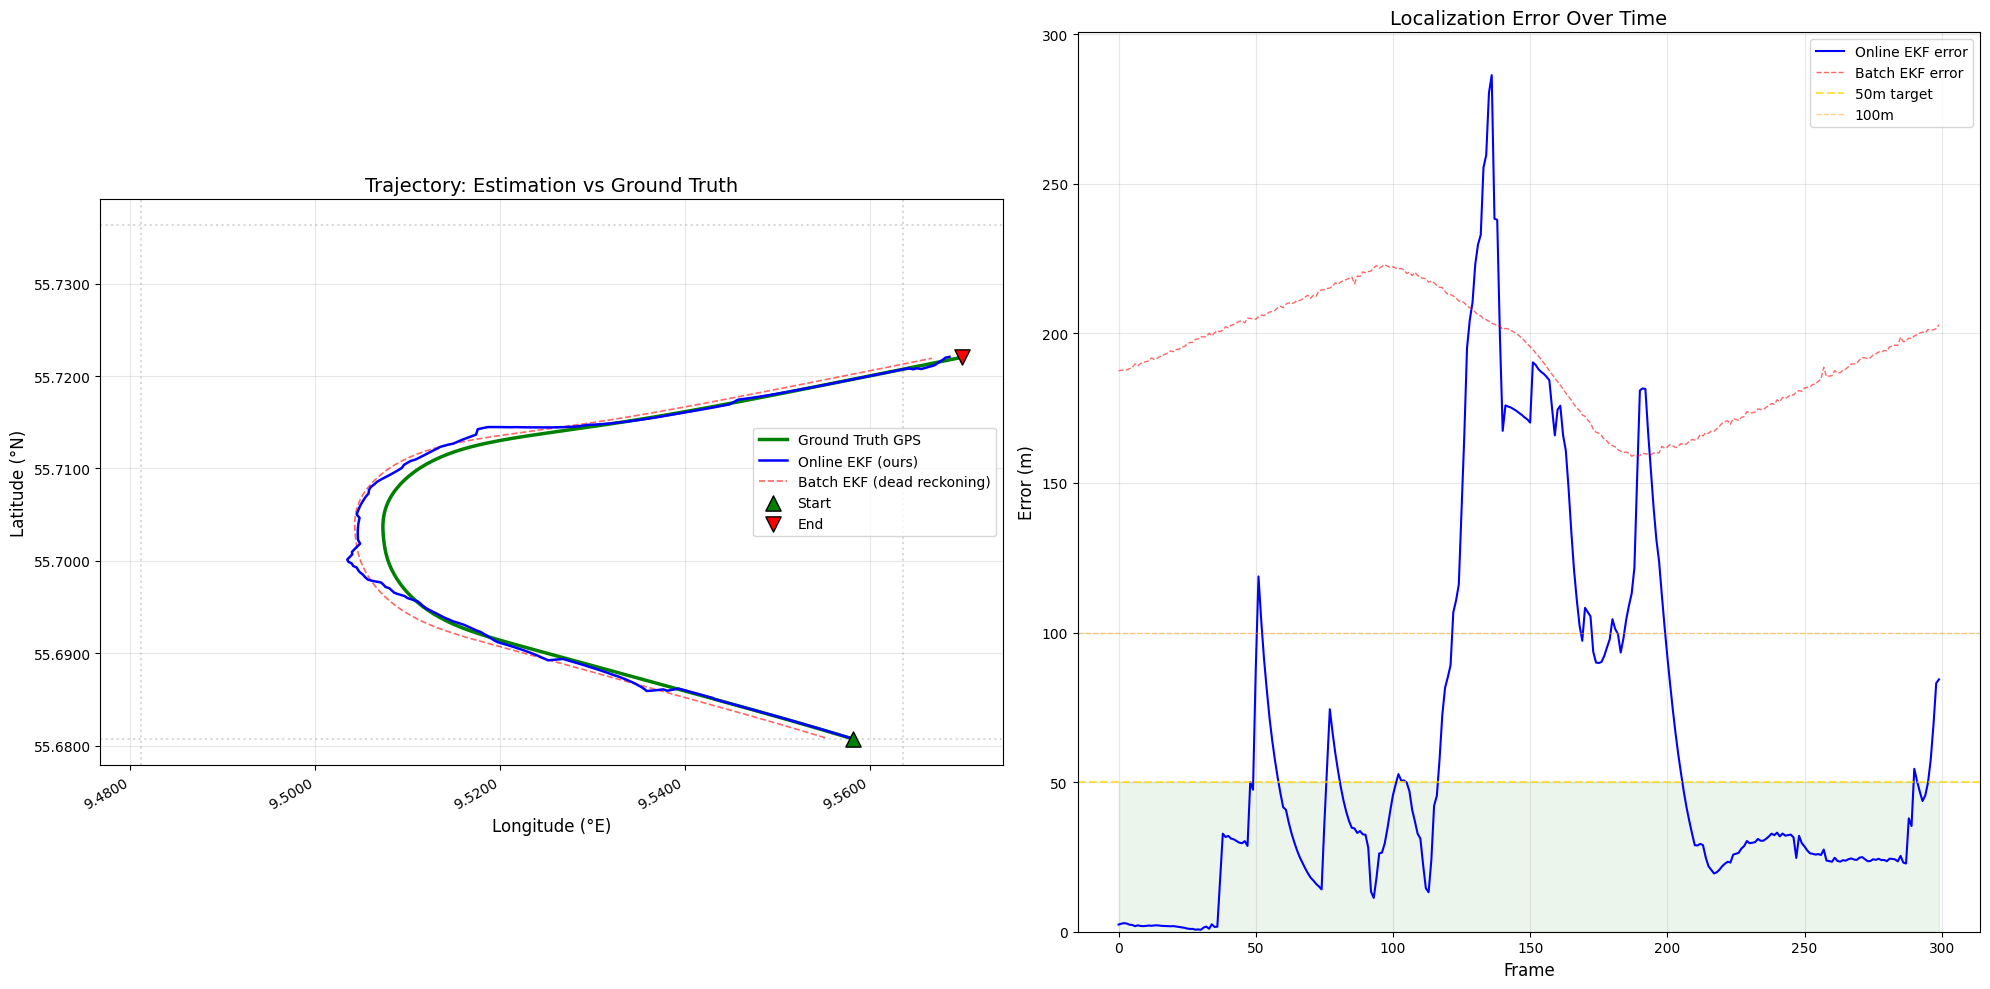

Saved: outputs/trajectory_vs_ground_truth.png


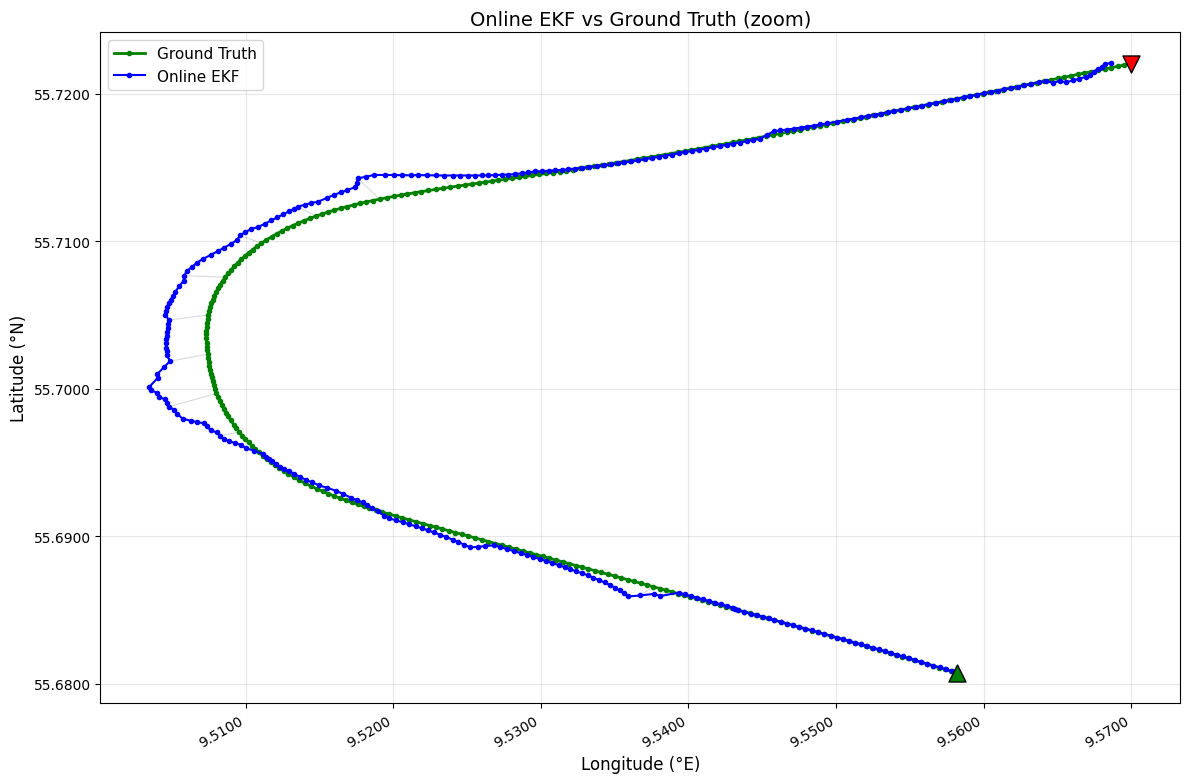

Saved: outputs/trajectory_zoomed.png


In [9]:
# Cell 6 — Trajectory Visualization: Estimation vs Ground Truth
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

est_lats  = [p[0] for p in trajectory_est]
est_lons  = [p[1] for p in trajectory_est]
gt_lats   = [p[0] for p in trajectory_gt]
gt_lons   = [p[1] for p in trajectory_gt]
bat_lats  = [p[0] for p in trajectory_batch]
bat_lons  = [p[1] for p in trajectory_batch]

# ─── Figure 1: Map view ───
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

ax = axes[0]
ax.plot(gt_lons, gt_lats, 'g-', lw=2.5, label='Ground Truth GPS', zorder=3)
ax.plot(est_lons, est_lats, 'b-', lw=1.8, label='Online EKF (ours)', zorder=4)
ax.plot(bat_lons, bat_lats, 'r--', lw=1.2, alpha=0.6, label='Batch EKF (dead reckoning)', zorder=2)

# Start/end markers
ax.scatter(gt_lons[0], gt_lats[0], c='green', s=120, marker='^', zorder=5, edgecolors='k', label='Start')
ax.scatter(gt_lons[-1], gt_lats[-1], c='red', s=120, marker='v', zorder=5, edgecolors='k', label='End')

# Reference map bounds
ax.axhline(map_bounds['lat_min'], color='gray', ls=':', alpha=0.3)
ax.axhline(map_bounds['lat_max'], color='gray', ls=':', alpha=0.3)
ax.axvline(map_bounds['lon_min'], color='gray', ls=':', alpha=0.3)
ax.axvline(map_bounds['lon_max'], color='gray', ls=':', alpha=0.3)

ax.set_xlabel('Longitude (°E)', fontsize=12)
ax.set_ylabel('Latitude (°N)', fontsize=12)
ax.set_title('Trajectory: Estimation vs Ground Truth', fontsize=14)
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# ─── Figure 2: Error over time ───
ax2 = axes[1]
frames = list(range(len(ekf_errors_online)))
ax2.plot(frames, ekf_errors_online, 'b-', lw=1.5, label='Online EKF error')
ax2.plot(frames, ekf_errors_batch, 'r--', lw=1, alpha=0.6, label='Batch EKF error')
ax2.axhline(50, color='gold', ls='--', lw=1.5, alpha=0.7, label='50m target')
ax2.axhline(100, color='orange', ls='--', lw=1, alpha=0.5, label='100m')
ax2.fill_between(frames, 0, 50, color='green', alpha=0.08)
ax2.set_xlabel('Frame', fontsize=12)
ax2.set_ylabel('Error (m)', fontsize=12)
ax2.set_title('Localization Error Over Time', fontsize=14)
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('../outputs/trajectory_vs_ground_truth.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: outputs/trajectory_vs_ground_truth.png")

# ─── Figure 3: Zoomed estimation close-up ───
fig2, ax3 = plt.subplots(figsize=(12, 10))

# Draw lines connecting estimation to GT for each frame (error vectors)
for i in range(0, len(est_lats), max(1, len(est_lats)//30)):
    ax3.plot([est_lons[i], gt_lons[i]], [est_lats[i], gt_lats[i]],
             'k-', alpha=0.15, lw=0.8)

ax3.plot(gt_lons, gt_lats, 'g-o', ms=3, lw=2, label='Ground Truth', zorder=3)
ax3.plot(est_lons, est_lats, 'b-o', ms=3, lw=1.5, label='Online EKF', zorder=4)
ax3.scatter(gt_lons[0], gt_lats[0], c='green', s=150, marker='^', zorder=5, edgecolors='k')
ax3.scatter(gt_lons[-1], gt_lats[-1], c='red', s=150, marker='v', zorder=5, edgecolors='k')

ax3.set_xlabel('Longitude (°E)', fontsize=12)
ax3.set_ylabel('Latitude (°N)', fontsize=12)
ax3.set_title('Online EKF vs Ground Truth (zoom)', fontsize=14)
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)
ax3.set_aspect('equal')
ax3.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
ax3.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
plt.setp(ax3.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('../outputs/trajectory_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: outputs/trajectory_zoomed.png")

Homo errors: mean=178m  median=107m  min=40m  max=897m  std=170m
  <50m: 1  <100m: 2  <150m: 41  <200m: 41

Gated (quality pass): mean homo err=112m (n=41)
Ungated (quality fail): mean homo err=479m (n=9)

Best 10 visual measurements:
  F 37: homo=   40m  CS=0.869  inl= 158  online=   17m  gate=Y
  F 38: homo=   92m  CS=0.881  inl= 123  online=   33m  gate=Y
  F 31: homo=  102m  CS=0.813  inl= 497  online=    1m  gate=Y
  F 34: homo=  103m  CS=0.819  inl= 342  online=    2m  gate=Y
  F 30: homo=  103m  CS=0.837  inl= 441  online=    1m  gate=Y
  F 29: homo=  104m  CS=0.811  inl= 559  online=    1m  gate=Y
  F 36: homo=  104m  CS=0.813  inl= 215  online=    2m  gate=Y
  F 28: homo=  104m  CS=0.812  inl= 575  online=    1m  gate=Y
  F 32: homo=  104m  CS=0.816  inl= 407  online=    2m  gate=Y
  F  0: homo=  105m  CS=0.810  inl= 391  online=    2m  gate=Y

Worst 10 visual measurements:
  F 49: homo=  129m  CS=0.685  inl= 175  online=   47m  gate=Y
  F 43: homo=  338m  CS=0.197  inl=   4  

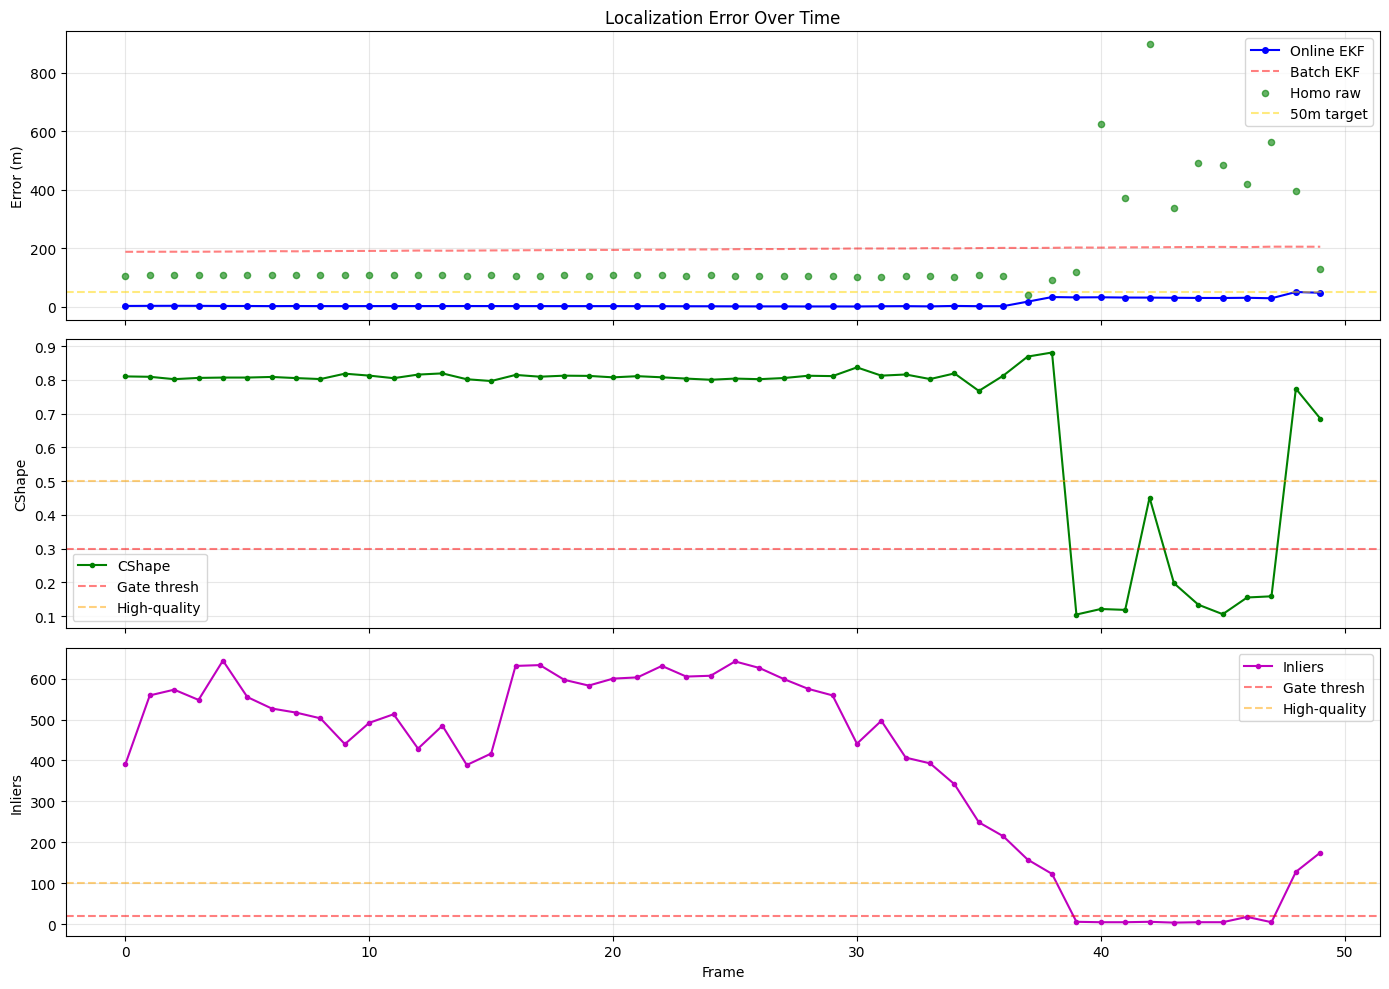

Saved: outputs/phase_c_diagnostics.png


In [11]:
# Cell 6 — Diagnostic: visual measurement accuracy vs quality metrics
import matplotlib.pyplot as plt
from src.tile_utils import haversine_distance as _hav

# Collect per-frame visual quality data
diag = []
for i, (csv_idx, ts, frame_path) in enumerate(aligned[:len(results)]):
    r = results[i]
    gt_row = imu_log.iloc[csv_idx]
    gt_lat, gt_lon = gt_row['gps_lat'], gt_row['gps_lon']
    hp = r.get('homo_position')
    vq = r.get('visual_quality', {})
    he = _hav(hp[0], hp[1], gt_lat, gt_lon) if hp else None
    diag.append({
        'frame': i, 'homo_err': he,
        'CShape': vq.get('CShape', 0), 'inliers': vq.get('inliers', 0),
        'gate': r.get('gate_pass', False),
        'online_err': ekf_errors_online[i], 'batch_err': ekf_errors_batch[i],
    })

# Distribution of homo errors
hes = [d['homo_err'] for d in diag if d['homo_err'] is not None]
print(f"Homo errors: mean={np.mean(hes):.0f}m  median={np.median(hes):.0f}m  "
      f"min={np.min(hes):.0f}m  max={np.max(hes):.0f}m  std={np.std(hes):.0f}m")
print(f"  <50m: {sum(1 for e in hes if e<50)}  <100m: {sum(1 for e in hes if e<100)}  "
      f"<150m: {sum(1 for e in hes if e<150)}  <200m: {sum(1 for e in hes if e<200)}")

# Quality vs accuracy correlation
gated = [d for d in diag if d['gate']]
ungated = [d for d in diag if not d['gate']]
if gated:
    ghe = [d['homo_err'] for d in gated if d['homo_err']]
    print(f"\nGated (quality pass): mean homo err={np.mean(ghe):.0f}m (n={len(ghe)})")
if ungated:
    uhe = [d['homo_err'] for d in ungated if d['homo_err']]
    if uhe:
        print(f"Ungated (quality fail): mean homo err={np.mean(uhe):.0f}m (n={len(uhe)})")

# Best 10 vs worst 10 visual measurements
sorted_diag = sorted([d for d in diag if d['homo_err'] is not None], key=lambda d: d['homo_err'])
print(f"\nBest 10 visual measurements:")
for d in sorted_diag[:10]:
    print(f"  F{d['frame']:3d}: homo={d['homo_err']:5.0f}m  CS={d['CShape']:.3f}  inl={d['inliers']:4d}  "
          f"online={d['online_err']:5.0f}m  gate={'Y' if d['gate'] else 'N'}")
print(f"\nWorst 10 visual measurements:")
for d in sorted_diag[-10:]:
    print(f"  F{d['frame']:3d}: homo={d['homo_err']:5.0f}m  CS={d['CShape']:.3f}  inl={d['inliers']:4d}  "
          f"online={d['online_err']:5.0f}m  gate={'Y' if d['gate'] else 'N'}")

# Plot: errors over time + quality markers
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

ax = axes[0]
ax.plot([d['frame'] for d in diag], [d['online_err'] for d in diag], 'b-o', ms=4, label='Online EKF')
ax.plot([d['frame'] for d in diag], [d['batch_err'] for d in diag], 'r--', alpha=0.5, label='Batch EKF')
he_frames = [d['frame'] for d in diag if d['homo_err']]
he_vals = [d['homo_err'] for d in diag if d['homo_err']]
ax.scatter(he_frames, he_vals, c='green', s=20, alpha=0.6, zorder=5, label='Homo raw')
ax.axhline(50, color='gold', ls='--', alpha=0.5, label='50m target')
ax.set_ylabel('Error (m)'); ax.legend(); ax.set_title('Localization Error Over Time')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot([d['frame'] for d in diag], [d['CShape'] for d in diag], 'g-o', ms=3, label='CShape')
ax.axhline(0.3, color='red', ls='--', alpha=0.5, label='Gate thresh')
ax.axhline(0.5, color='orange', ls='--', alpha=0.5, label='High-quality')
ax.set_ylabel('CShape'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot([d['frame'] for d in diag], [d['inliers'] for d in diag], 'm-o', ms=3, label='Inliers')
ax.axhline(20, color='red', ls='--', alpha=0.5, label='Gate thresh')
ax.axhline(100, color='orange', ls='--', alpha=0.5, label='High-quality')
ax.set_ylabel('Inliers'); ax.set_xlabel('Frame'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/phase_c_diagnostics.png', dpi=150)
plt.show()
print("Saved: outputs/phase_c_diagnostics.png")

Gated frames analyzed: 41
Offset distance: mean=112m  std=46m
Offset angle (relative to heading): mean=-68.5°  std=159.4°
  (0° = exactly forward, ±180° = behind drone)

>>> Offset NOT aligned with heading. Mean angle = -68.5°
>>> Look for other systematic bias sources.

Per-frame offset details (worst 10):
  F 48: dist=  395m  offset_bearing= 65.2°  heading=-64.0°  diff=+129.3°
  F 49: dist=  129m  offset_bearing=100.9°  heading=-64.0°  diff=+165.0°
  F  9: dist=  109m  offset_bearing=118.5°  heading=-62.4°  diff=-179.1°
  F 13: dist=  109m  offset_bearing=118.3°  heading=-62.8°  diff=-178.9°
  F  7: dist=  108m  offset_bearing=118.6°  heading=-62.2°  diff=-179.2°
  F  3: dist=  108m  offset_bearing=118.9°  heading=-61.9°  diff=-179.2°
  F  8: dist=  108m  offset_bearing=118.8°  heading=-62.3°  diff=-178.8°
  F  6: dist=  108m  offset_bearing=119.0°  heading=-62.1°  diff=-178.9°
  F 35: dist=  108m  offset_bearing=113.5°  heading=-63.8°  diff=+177.3°
  F  4: dist=  108m  offset_bearin

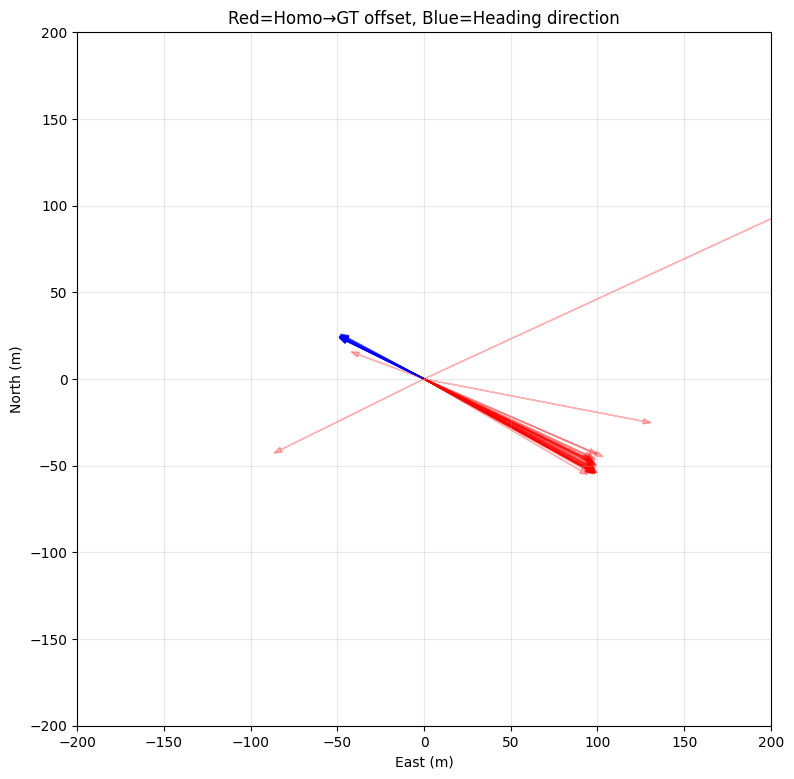

In [12]:
# Cell 7 — Camera look-ahead diagnosis: is the offset in the heading direction?
import math

# For each gated frame, compute: offset vector (homo → GT), heading vector, angle between them
offset_analysis = []
for i, (csv_idx, ts, frame_path) in enumerate(aligned[:len(results)]):
    r = results[i]
    hp = r.get('homo_position')
    if hp is None or not r.get('gate_pass', False):
        continue
    gt_row = imu_log.iloc[csv_idx]
    gt_lat, gt_lon = gt_row['gps_lat'], gt_row['gps_lon']
    
    # Offset vector: homo → GT (meters, NED convention)
    d_north = (gt_lat - hp[0]) * 111320  # approx m per degree lat
    d_east = (gt_lon - hp[1]) * 111320 * math.cos(math.radians(gt_lat))
    offset_dir = math.degrees(math.atan2(d_east, d_north)) % 360  # bearing of (homo → GT)
    offset_dist = math.sqrt(d_north**2 + d_east**2)
    
    # Drone heading (from EKF)
    ekf_state_snap = r.get('visual_quality', {})
    # We need heading from imu_data used during processing — use ekf yaw from imu_log
    heading = gt_row['yaw_deg'] if 'yaw_deg' in gt_row.index else 0.0
    
    # Angle between offset direction and heading (should be ~0 if camera looks forward)
    angle_diff = (offset_dir - heading + 180) % 360 - 180  # [-180, 180]
    
    offset_analysis.append({
        'frame': i, 'offset_dist': offset_dist,
        'offset_dir': offset_dir, 'heading': heading,
        'angle_diff': angle_diff, 'd_north': d_north, 'd_east': d_east
    })

# Summary
dists = [o['offset_dist'] for o in offset_analysis]
angles = [o['angle_diff'] for o in offset_analysis]
print(f"Gated frames analyzed: {len(offset_analysis)}")
print(f"Offset distance: mean={np.mean(dists):.0f}m  std={np.std(dists):.0f}m")
print(f"Offset angle (relative to heading): mean={np.mean(angles):.1f}°  std={np.std(angles):.1f}°")
print(f"  (0° = exactly forward, ±180° = behind drone)")
print()

# If mean angle is near 0°, the offset is in the heading direction → camera look-ahead confirmed
if abs(np.mean(angles)) < 30:
    print(">>> CONFIRMED: Offset is primarily in the heading direction!")
    print(">>> This is consistent with a fixed camera forward-tilt.")
    altitude = 365  # approximate altitude in meters
    tilt_est = math.degrees(math.atan(np.mean(dists) / altitude))
    print(f">>> Estimated camera tilt: {tilt_est:.1f}° (at {altitude}m altitude)")
else:
    print(f">>> Offset NOT aligned with heading. Mean angle = {np.mean(angles):.1f}°")
    print(">>> Look for other systematic bias sources.")

# Per-frame details for worst offsets
print(f"\nPer-frame offset details (worst 10):")
for o in sorted(offset_analysis, key=lambda x: x['offset_dist'], reverse=True)[:10]:
    print(f"  F{o['frame']:3d}: dist={o['offset_dist']:5.0f}m  "
          f"offset_bearing={o['offset_dir']:5.1f}°  heading={o['heading']:5.1f}°  "
          f"diff={o['angle_diff']:+6.1f}°")

# Plot offset vectors
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
for o in offset_analysis:
    # Arrow from origin in heading direction
    hrad = math.radians(o['heading'])
    ax.arrow(0, 0, math.sin(hrad)*50, math.cos(hrad)*50, 
             head_width=3, color='blue', alpha=0.15)
    # Arrow showing actual offset
    ax.arrow(0, 0, o['d_east'], o['d_north'], 
             head_width=3, color='red', alpha=0.3)
ax.set_xlabel('East (m)'); ax.set_ylabel('North (m)')
ax.set_title('Red=Homo→GT offset, Blue=Heading direction')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_xlim(-200, 200); ax.set_ylim(-200, 200)
plt.tight_layout()
plt.show()